In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

## This for the basic boilder plate

##  Explained Variance Ratio Difference

In probability theoury and statistics, variance is the expected value of the squared deviation from the mean of a random variable.


Explained variance is a measure of how much of the total variance in the original dataset is explained by each PC.


Explained variace ratio is simply percentange of variance (info) captured by each principal compoenent

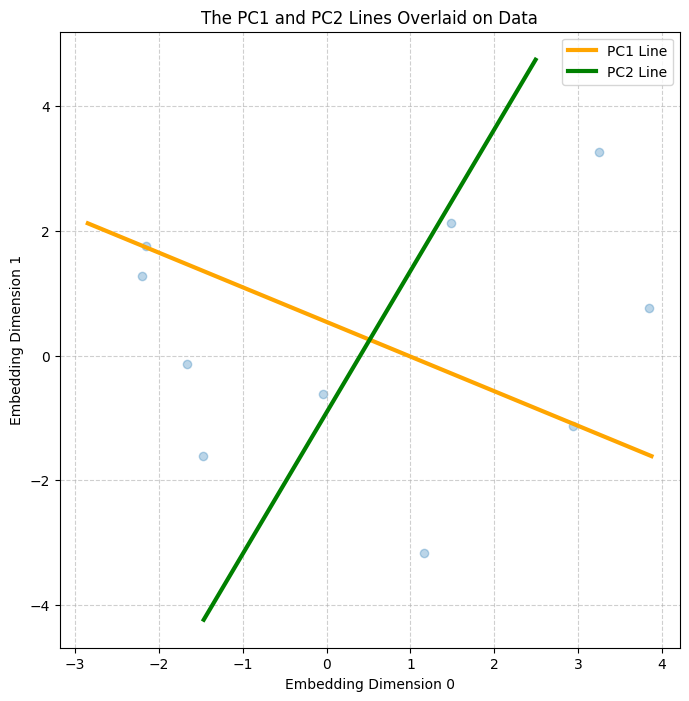

In [3]:
''' Let's load the model with skeleton in same configuration '''
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from script.shell import MinimalTransformer

checkpoint_dir = os.path.join(PROJECT_ROOT, 'checkpoints')
file_name = 'v1.pth'
full_path = os.path.join(checkpoint_dir, file_name)


if not os.path.exists(full_path):
    sys.exit()    # re-run the train and see, this script is for analysis

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab_size = 10

''' Important note we can't import the original transfoemr cause there, we have different hyperparamaster initlized. '''

model = MinimalTransformer(vocab_size=vocab_size)
model.load_state_dict(torch.load(full_path, map_location=device)) # loaded into transformer

embedding_learned = model.token_embed # token embedding is vocab_size X d_model
B, T = embedding_learned.weight.shape

embedding_matrix = embedding_learned.weight.detach()

X = embedding_matrix.cpu().numpy() 

pca = PCA(n_components=8)
X_pca = pca.fit_transform(X)


components = pca.components_       

components = pca.components_  
mean_val = pca.mean_         

plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3)


length = 8


p1_start = mean_val[:2] - components[0, :2] * length
p1_end = mean_val[:2] + components[0, :2] * length
plt.plot([p1_start[0], p1_end[0]], [p1_start[1], p1_end[1]], 
         color='orange', linewidth=3, label='PC1 Line')


p2_start = mean_val[:2] - components[1, :2] * length
p2_end = mean_val[:2] + components[1, :2] * length
plt.plot([p2_start[0], p2_end[0]], [p2_start[1], p2_end[1]], 
         color='green', linewidth=3, label='PC2 Line')

plt.xlabel("Embedding Dimension 0")
plt.ylabel("Embedding Dimension 1")
plt.title("The PC1 and PC2 Lines Overlaid on Data")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Now we want to plot the Cumilative Explained Variance Ratio vs Cumilative Explaned Variance Ratio by PCA


In [4]:
explained_variance = pca.explained_variance_
total_explained_variance = explained_variance.sum()


print(f"Explained Variance:\n{explained_variance}")
print(f"Total Explained Variance: {total_explained_variance:.4f}")

Explained Variance:
[9.6031332e+00 7.3077412e+00 6.2882681e+00 5.0091758e+00 3.4983034e+00
 4.4352692e-03 1.5278659e-03 1.2738663e-05]
Total Explained Variance: 31.7126


In [5]:
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
total_explained_variance_ratio = explained_variance_ratio.sum()

# Print results
print(f"\nExplained Variance Ratio:\n{explained_variance_ratio}")
print(f"Total Explained Variance Ratio: {total_explained_variance_ratio:.4f}")


Explained Variance Ratio:
[3.0281761e-01 2.3043655e-01 1.9828929e-01 1.5795539e-01 1.1031274e-01
 1.3985828e-04 4.8178517e-05 4.0169095e-07]
Total Explained Variance Ratio: 1.0000


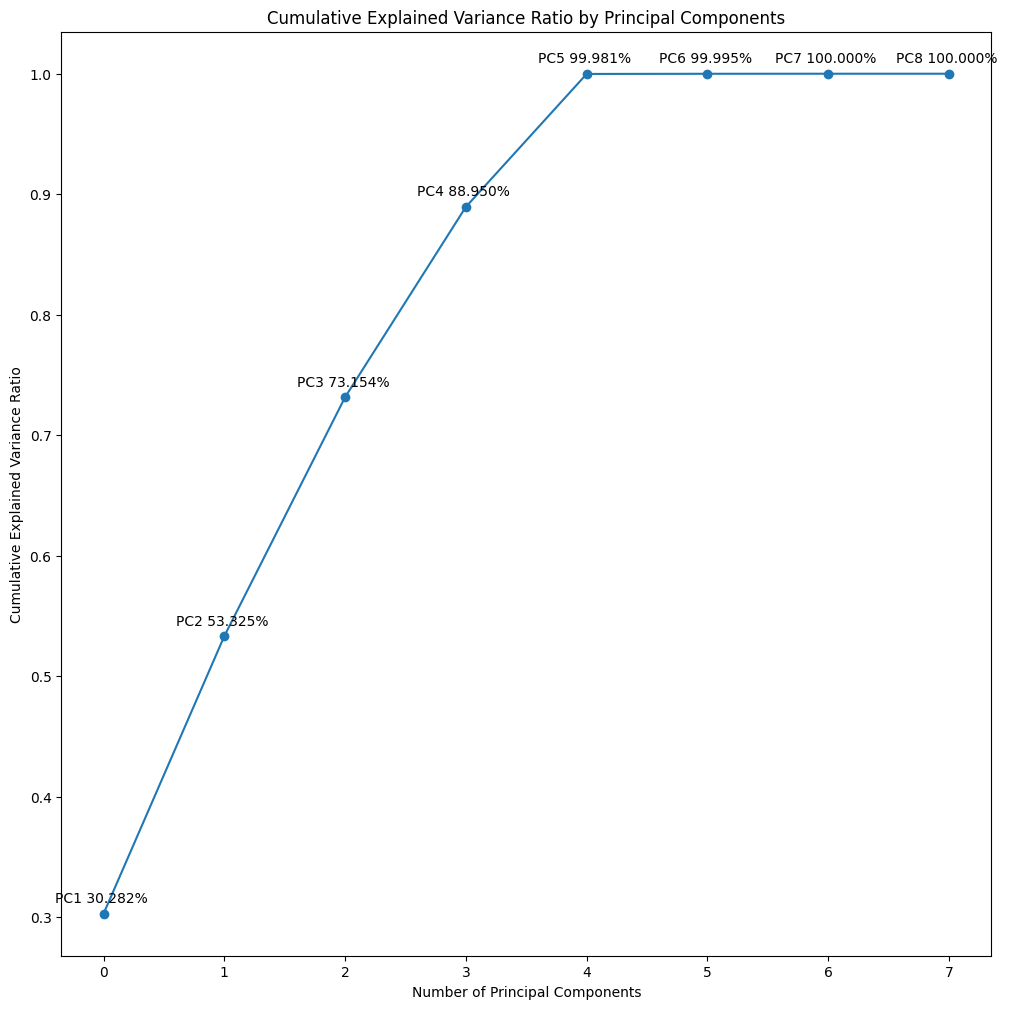

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(12, 12))
plt.plot(cumulative_variance_ratio, marker='o')

for i, val in enumerate(cumulative_variance_ratio):
    plt.annotate(f'PC{i+1} {val:.3%} ', 
                 (i, val), 
                 textcoords="offset points", 
                 xytext=(0,8), 
                 ha='center')

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio by Principal Components')

plt.show()